# Exercício sobre regressão de preços de residências usando redes neurais densas (DNNs)

Neste exercício, você irá treinar a mesma rede neural do exemplo visto em sala de aula.

Entretanto, nenhum escalonamento (padronização ou normalização) será aplicado aos atributos.

**Execute todas as células de código abaixo, analise e compare os resultados obtidos abaixo com aqueles obtidos no exemplo visto em sala de aula e, ao final, conclua se o escalonamento é benéfico ou não? Ou seja, vale a pena escalonar?** (**Justifique todas as suas respostas**).

## Importando as bibliotecas

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Deixa o resultado reproduzivel
tf.keras.utils.set_random_seed(42)


## Baixando a base de dados

Neste exercício, utilizaremos uma rede neural para aproximar o conjunto de dados do Boston Housing e predizer o custo médio de uma casa em uma área de Boston.

**Objetivo**

O objetivo é treinar um **modelo de regressão** que prediga o valor médio das casas naquela área usando os 13 atributos fornecidos.

**Observação**

Por padrão, a função `load_data` divide o conjunto total de exemplos em 80% para treinamento e 20% para testes.

In [2]:
data = tf.keras.datasets.boston_housing

(x_train, y_train), (x_test, y_test) = data.load_data()

## Definindo o modelo

In [3]:
# Guarda a quantidade de atributos de entrada
input_shape = x_train.shape[1]

print('Quantidade de atributos:', input_shape)


Quantidade de atributos: 13


In [4]:
# Cria o modelo sem escalonar os dados
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(input_shape,)),
    tf.keras.layers.Dense(20, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 301 (1.18 KB)

 Trainable params: 301 (1.18 KB)

 Non-trainable params: 0 (0.00 B)

## Compilando o modelo

In [5]:
# Compila o modelo
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


## Treinando o modelo


In [6]:
# Treina o modelo com os dados sem escalonamento
history = model.fit(
    x_train,
    y_train,
    epochs=1000,
    verbose=0
)

print('Treinamento finalizado.')


Treinamento finalizado.


### Avaliando o modelo treinado no conjunto de treinamento

In [7]:
# Avalia o modelo no conjunto de treinamento
train_eval = model.evaluate(x_train, y_train, verbose=0)

print('MSE no conjunto de treinamento: {:.5}'.format(train_eval[0]))
print('MAE no conjunto de treinamento: {:.5}'.format(train_eval[1]))


MSE no conjunto de treinamento: 9.8186
MAE no conjunto de treinamento: 2.2896


### Plotando os erros

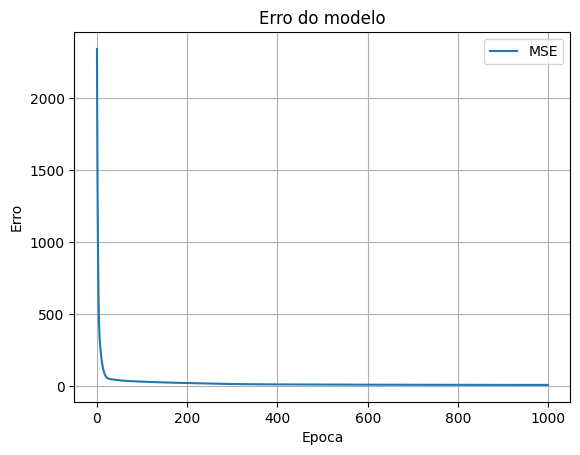

In [8]:
# Plota o MSE do treinamento
plt.plot(history.history['loss'], label='MSE')
plt.title('Erro do modelo')
plt.ylabel('Erro')
plt.xlabel('Epoca')
plt.legend(loc='upper right')
plt.grid()
plt.show()


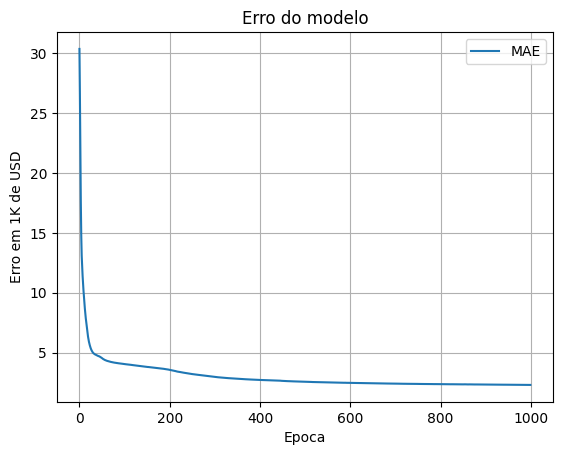

In [9]:
# Plota o MAE do treinamento
plt.plot(history.history['mae'], label='MAE')
plt.title('Erro do modelo')
plt.ylabel('Erro em 1K de USD')
plt.xlabel('Epoca')
plt.legend(loc='upper right')
plt.grid()
plt.show()


## Testando o modelo treinado no conjunto de teste
### Medindo a capacidade de generalização



In [10]:
# Avalia o modelo no conjunto de teste
test_eval = model.evaluate(x_test, y_test, verbose=0)

print('MSE no conjunto de teste: {:.5}'.format(test_eval[0]))
print('MAE no conjunto de teste: {:.5}'.format(test_eval[1]))


MSE no conjunto de teste: 26.799
MAE no conjunto de teste: 3.5834


#### Comparando os 5 primeiros valores preditos com o esperados.

In [11]:
# Faz as predicoes no conjunto de teste
y_hat = model.predict(x_test, verbose=0)

print(y_hat[:5])


[[11.379803]
 [17.978737]
 [22.238026]
 [34.615574]
 [23.77907 ]]


In [12]:
# Mostra os valores esperados das primeiras amostras
print(y_test[:5])


[ 7.2 18.8 19.  27.  22.2]


#### Comparando os histogramas dos valores preditos e esperados.

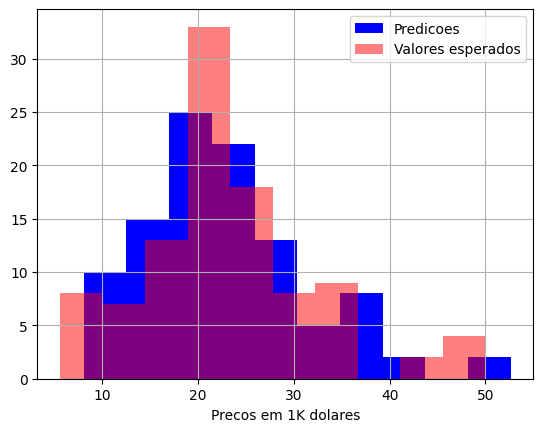

In [13]:
# Compara os histogramas
plt.hist(y_hat, label='Predicoes', color='b')
plt.hist(y_test, label='Valores esperados', color='r', alpha=0.5)
plt.xlabel('Precos em 1K dolares')
plt.legend()
plt.grid()
plt.show()


### Resposta

Sem escalonamento, os atributos entram na rede em escalas muito diferentes. Isso dificulta o treinamento, porque alguns atributos dominam mais o calculo do gradiente do que outros.

Comparando com o exemplo escalonado visto em aula, vale a pena escalonar os dados. A padronizacao ajuda o otimizador a encontrar pesos melhores com mais estabilidade e geralmente reduz o erro final do modelo.
